## Linear Regression

### utils and helper imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lars
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split

### #Import dataset

In [4]:

dataset = pd.read_csv("res/Salary_Data.csv")
X = dataset.iloc[:, :-1].values
Y = dataset.iloc[:, 1].values
print("X and Y")
print(X, "\n\n", Y.reshape(-1,1), "\n")

#Splitting the dataset into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("X train and test")
print(X_train, "\n\n", X_test, "\n")
print("Y train and test")
print(Y_train.reshape(-1,1), "\n\n", Y_test.reshape(-1,1), "\n")


X and Y
[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]] 

 [[ 39343.]
 [ 46205.]
 [ 37731.]
 [ 43525.]
 [ 39891.]
 [ 56642.]
 [ 60150.]
 [ 54445.]
 [ 64445.]
 [ 57189.]
 [ 63218.]
 [ 55794.]
 [ 56957.]
 [ 57081.]
 [ 61111.]
 [ 67938.]
 [ 66029.]
 [ 83088.]
 [ 81363.]
 [ 93940.]
 [ 91738.]
 [ 98273.]
 [101302.]
 [113812.]
 [109431.]
 [105582.]
 [116969.]
 [112635.]
 [122391.]
 [121872.]] 

X train and test
[[ 3.9]
 [ 9.5]
 [ 8.7]
 [ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]
 [ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]] 

 [[ 1.5]
 [10.3]
 [ 4.1]] 

Y train and test
[[ 63218.]
 [116969.]
 [109431.]
 [112635.]
 [ 55794.]
 [ 83088.]
 [101302.]
 [ 56642.]
 [ 66029.]
 [ 64445.]
 [ 61111.]
 [113812.]
 [


### Fitting Simple Linear Regression to the Training Set

LinearRegression() 

Y prediction 

[[ 40628.97301142]
 [123152.87216178]
 [ 65011.03412402]] 



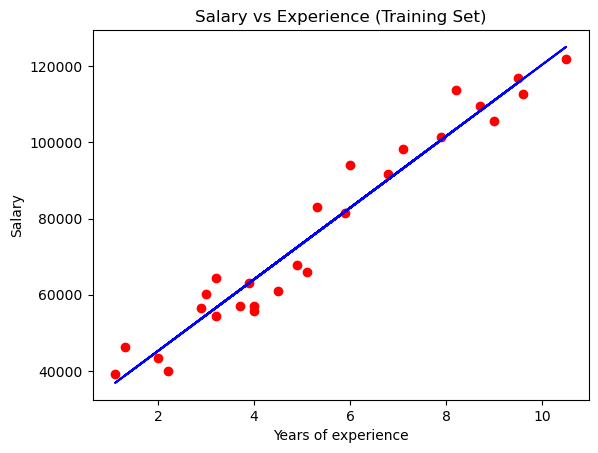

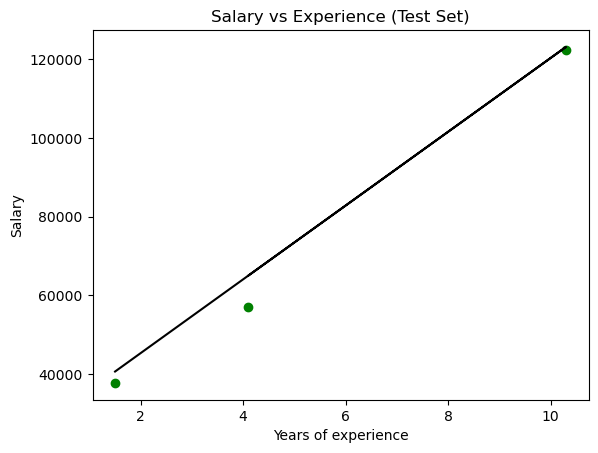

In [5]:

regressor = LinearRegression()
regressor.fit(X_train, Y_train)
print(regressor,"\n")

#Predicting the test set results
# Y_pred = regressor.predict(X_test)
Y_pred = regressor.coef_*(X_test) + regressor.intercept_

print("Y prediction","\n")
print(Y_pred.reshape(-1,1),"\n")

#Visualizing the Training Set Results
plt.scatter(X_train, Y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title("Salary vs Experience (Training Set)")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.show()

#Visualizing the Test Set Results
plt.scatter(X_test, Y_test, color='green')
plt.plot(X_test, Y_pred, color='black')
plt.title("Salary vs Experience (Test Set)")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.show()

# Logistic Regression

### utils and Importing the libraries

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix,accuracy_score


def plot_boundary(X_set,Y_set, clf):
    #Visualizing Testing Set Results
    from matplotlib.colors import ListedColormap
    colors =["green", "orange", "gold", "blue", "k", "purple","red"]

    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                        np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                                        alpha = 0.75, cmap = ListedColormap(colors))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate (np.unique(Y_set)):
        plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],
                    c = ListedColormap(colors)(i), label = j)
    plt.title('Classify users if they buy the Car')
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')
    plt.legend()
    plt.show()



### Load dataset

In [7]:
dataset = pd.read_csv('res/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
Y = dataset.iloc[:, 4].values

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Fit Model on dataset 

[[65  3]
 [ 8 24]]
0.89


C:\Users\wasie\AppData\Local\Temp\ipykernel_16284\2026863300.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],


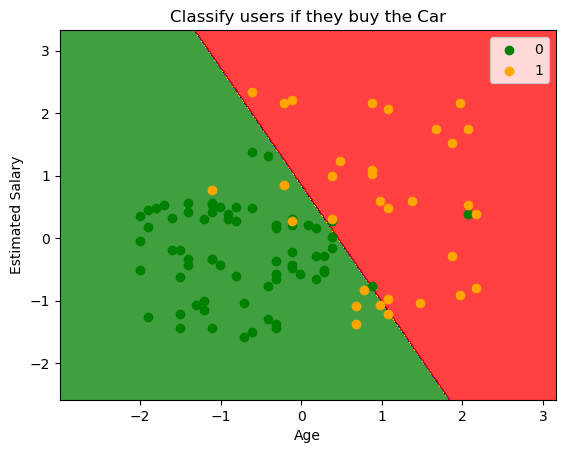

[[64  4]
 [ 3 29]]
0.93


C:\Users\wasie\AppData\Local\Temp\ipykernel_16284\2026863300.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],


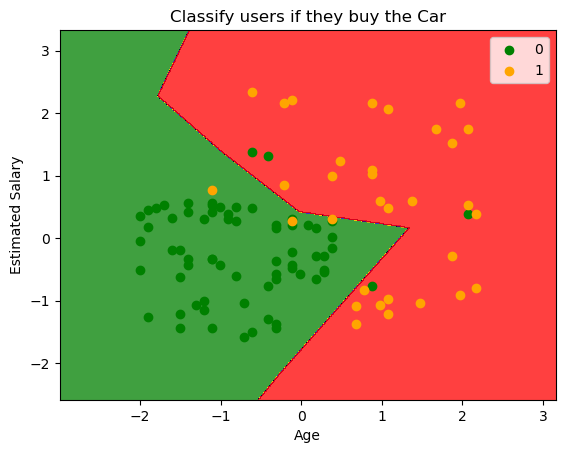

In [8]:
#Fitting Logistic Regression to the Training Set
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
classifier = LogisticRegression()    ###SVC()
classifier.fit(X_train, Y_train)

#Predicting the Test set results
Y_pred = classifier.predict(X_test)

#Making the Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm) #shows the number of correct predictions made
result_acc = accuracy_score(Y_test, Y_pred)
print(result_acc)

plot_boundary(X_test, Y_test, classifier)



from sklearn.neural_network import MLPClassifier
classifier_nn = MLPClassifier(solver='lbfgs', alpha=1e-4,
                    hidden_layer_sizes=(5, 2), random_state=1)

classifier_nn.fit(X_train, Y_train)

#Predicting the Test set results
Y_pred = classifier_nn.predict(X_test)

#Making the Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm) #shows the number of correct predictions made
result_acc = accuracy_score(Y_test, Y_pred)
print(result_acc)


plot_boundary(X_test, Y_test, classifier_nn)


# Linear Classifier

### Imports and utils 

In [9]:
from sklearn.datasets import make_classification
from sklearn.datasets import make_circles
import numpy as np
import matplotlib.pyplot as plt


class LinearClassifier:
    def __init__(self):
        pass
    def sigmoid(self,z):
        return 1.0/(1. + np.exp(-z))

    def loss(self,y,y_ht):
        loss =  -np.mean( y*(np.log(y_ht)) - (1-y)*np.log(1-y_ht) )
        return loss

    def gradient(self,x,y,y_ht):
        m = x.shape[0]
        dw = (1/m)*np.dot(x.T,(y_ht-y)) #wrt w
        db = (1/m)*np.sum((y_ht-y)) # wrt bias
        return dw,db 

    def normalize(self,x):
        m,n = x.shape   #m : trg exmple, n: features
        for i in range(n):
            x = (x - x.mean(axis=0))/x.std(axis=0)
        return x    

    def train(self, x,y,bs,epochs,lr):
        m,n = x.shape
        w = np.zeros((n,1))  ## or random ?
        b = 0
        y = y.reshape(m,1)
        x = self.normalize(x)

        losses = []

        for epoch in range(epochs):
            for i in range((m-1)//bs+1):
                start_i = i*bs
                end_i = start_i + bs
                xb = x[start_i:end_i]
                yb = y[start_i:end_i]

                y_ht = self.sigmoid(np.dot(xb,w)+b)

                dw,db = self.gradient(xb,yb,y_ht)

                w -=lr*dw
                b -=lr*db

            l = self.loss(y,self.sigmoid(np.dot(x,w)+b))
            losses.append(l)
            # self.plot_dec_boundry(x,w,b,y,1)

        return w,b,losses


    def predict(self,x,w,b):

        x = self.normalize(x)
        preds = self.sigmoid((np.dot(x,w)+b))
        pred_class = []

        pred_class = [1 if i>0.5 else 0 for i in preds]

        return np.array(pred_class)
    
    def accuracy(self,y, y_ht):
        accuracy = np.sum(y == y_ht) / len(y)
        return accuracy

    def plot_dec_boundry(self,x,w,b,y,debug):
        x1 = [min(x[:,0]), max(x[:,0])]
        m = -w[0]/w[1]
        c = -b/w[1]
        x2 = m*x1 + c
        plt.plot(x[:,0][y==0], x[:,1][y==0],'r^')
        plt.plot(x[:,0][y==1], x[:,1][y==1],'bs')
        plt.plot(x1,x2,'y-')
        if debug:
            plt.show()


### init and fit Classifier 

[[-1.87346774]
 [-1.93479642]] 0.4634671222559593
Accuracy=  93.0 %


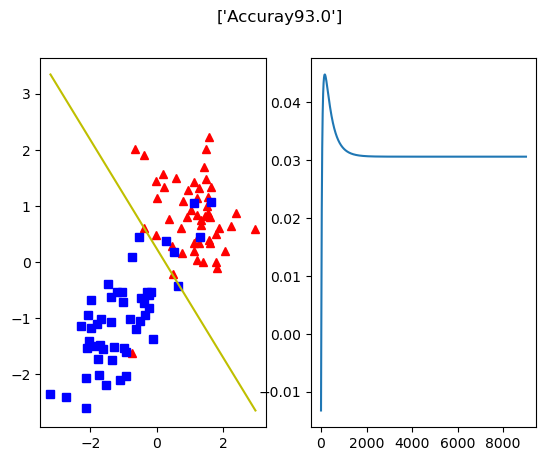

In [10]:
x,Y = make_classification(n_features=2,n_classes=2,n_samples=100,n_redundant=0,n_clusters_per_class=1)
# x,Y = make_circles(n_samples=100,noise=0.03,factor=0.7)

p = LinearClassifier()
w,b,loss = p.train(x,Y,bs=10,epochs=9000,lr=0.01)
print(w,b)
class_pred = p.predict(x,w,b)
print('Accuracy= ',p.accuracy(Y,class_pred) * 100,'%')
plt.subplot(1,2,1)
p.plot_dec_boundry(x,w,b,Y,0)
plt.subplot(1,2,2)
plt.plot(loss)
plt.suptitle(['Accuray' + str(p.accuracy(Y,class_pred) * 100)])
plt.show()


